## 시계열 데이터 분석
> 시간의 흐름에 따라 순차적으로 관측된 데이터의 분석 패턴을 이해하고, 미래예측하거나, 이상 현상 탐지하는 분석 방법

In [1]:
# 시계열 분석에서 가장 중요한 기초는 datetime 자료형을 다루는 것임.

# 매출 데이터셋[주문날짜, 매출]
import pandas as pd

df = pd.read_csv('./data_set/sales_data.csv')
df

,order_date,sales
0,2024-01-01,120
1,2024-01-02,135
2,2024-01-03,128
3,2024-01-04,142
4,2024-01-05,150
5,2024-01-06,160
6,2024-01-07,155
7,2024-01-08,170
8,2024-01-09,165
9,2024-01-10,180


In [3]:
# 자료형 확인
df.dtypes

order_date    object
sales          int64
dtype: object

In [4]:
#문자열을 datetime으로 변환
df['order_date'] = pd.to_datetime(df['order_date'])
df.dtypes

order_date    datetime64[ns]
sales                  int64
dtype: object

In [5]:
# 주문날짜를 인덱스로 설정.. 시계열 분석이 용이.
df = df.set_index('order_date')
df.head(3)

,sales
order_date,
2024-01-01,120
2024-01-02,135
2024-01-03,128


In [6]:
# 인덱스를 그냥 써도 되지만.. 경우에 따라 연도별, 달별, 요일별 로 구분하여 보고 싶을 수 있음.
# 연,월,요일에 대한 파생변수 만들어 보기
df['year']=df.index.year
df['month']=df.index.month
df['weekday']=df.index.weekday # 월:0 ~ 일:6
df

,sales,year,month,weekday
order_date,,,,
2024-01-01,120,2024,1,0
2024-01-02,135,2024,1,1
2024-01-03,128,2024,1,2
2024-01-04,142,2024,1,3
2024-01-05,150,2024,1,4
2024-01-06,160,2024,1,5
2024-01-07,155,2024,1,6
2024-01-08,170,2024,1,0
2024-01-09,165,2024,1,1


In [7]:
# 특정 기간 필터링 -- 슬라이싱
df_2024 = df['2024-01-03':'2024-01-07']
df_2024

,sales,year,month,weekday
order_date,,,,
2024-01-03,128,2024,1,2
2024-01-04,142,2024,1,3
2024-01-05,150,2024,1,4
2024-01-06,160,2024,1,5
2024-01-07,155,2024,1,6


In [8]:
# 주별로 매출 데이터를 보고 싶음... -- groupby와 비슷하게 한 주단위로 그룹하기!!
weekly_sales = df['sales'].resample('W').mean() #평균 판매량
weekly_sales

order_date
2024-01-07    141.428571
2024-01-14    171.666667
Freq: W-SUN, Name: sales, dtype: float64

In [9]:
# 요일별 매출 데이터를 보고 싶음.. -- groupby로 구현해보기
weekly_avg_sales = df.groupby(df.index.weekday)['sales'].mean()
weekly_avg_sales

order_date
0    145.0
1    150.0
2    154.0
3    142.0
4    150.0
5    160.0
6    155.0
Name: sales, dtype: float64

In [10]:
# 시계열 데이터는 바로 이전 데이터와의 차이를 중요한 분석값으로 활용하는 경우가 많음.
# 즉, 현재 값 자체보다 이전 시점과 얼마나 달라졌는가(변화량)를 분석..
# 예) 주식 가격 변동, 일별 매출 증가량, 일일 기온 변화

# 변동률계산 = (오늘매출-전일매출)/전일매출 * 100

# 데이터셋에는 보통 현재 매출데이터만 있으니.. 전일 매출 데이터와의 계산을 편하게 하려면..
# 전일 매출데이터를 새로운 컬룸으로 추가해 놓는 경우가 많음.

# 전일 매출 컬룸 새로 생성하기
df['prev_sales']= df['sales'].shift(1) #한 행씩 아래로 내리기..

#전일 대비 매출 증감률
df['sales_change_rate']= ( df['sales']-df['prev_sales']) / df['prev_sales'] * 100
df

,sales,year,month,weekday,prev_sales,sales_change_rate
order_date,,,,,,
2024-01-01,120,2024,1,0,NaN,NaN
2024-01-02,135,2024,1,1,120.0,12.500000
2024-01-03,128,2024,1,2,135.0,-5.185185
2024-01-04,142,2024,1,3,128.0,10.937500
2024-01-05,150,2024,1,4,142.0,5.633803
2024-01-06,160,2024,1,5,150.0,6.666667
2024-01-07,155,2024,1,6,160.0,-3.125000
2024-01-08,170,2024,1,0,155.0,9.677419
2024-01-09,165,2024,1,1,170.0,-2.941176


In [11]:
# 비율말고..그냥 변화량의 수치만 보고 싶다면.. 뺄셈계산만 수행...해주는 기능
df['sales_diff']= df['sales'].diff()
df

,sales,year,month,weekday,prev_sales,sales_change_rate,sales_diff
order_date,,,,,,,
2024-01-01,120,2024,1,0,NaN,NaN,NaN
2024-01-02,135,2024,1,1,120.0,12.500000,15.0
2024-01-03,128,2024,1,2,135.0,-5.185185,-7.0
2024-01-04,142,2024,1,3,128.0,10.937500,14.0
2024-01-05,150,2024,1,4,142.0,5.633803,8.0
2024-01-06,160,2024,1,5,150.0,6.666667,10.0
2024-01-07,155,2024,1,6,160.0,-3.125000,-5.0
2024-01-08,170,2024,1,0,155.0,9.677419,15.0
2024-01-09,165,2024,1,1,170.0,-2.941176,-5.0


### 주피터노트북에 새로운 모듈 설치
1. conda 프롬프트 환경에서 직접 pip install or conda install 로 모듈 설치
2. 주피너 노트북 쉘환경에서 !pip install or !conda install로 모듈 설치
3. 1회용으로 설치하기 %pip install or %conda install로 모듈 설치

In [12]:
# 주식 데이터 불러오기 -- 책. pandas-datareader 모듈.. 버전이 안 맞아서. 'qtooq'인자를 인식못함

In [13]:
# 주식 데이터 불러오는 모듈 yfinance
%pip install yfinance

  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached peewee-4.2.6-py3-none-any.whl.metadata (10 kB)
  Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl.metadata (18 kB)
Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl (1.7 MB)
Using cached multitasking-0.0.13-py3-none-any.whl (16 kB)
Using cached peewee-4.2.6-py3-none-any.whl (173 kB)

   ---------------------------------------- 0/5 [peewee]
   ---------------- ----------------------- 2/5 [websockets]
   ------------------------ --------------- 3/5 [curl_cffi]
   -------------------------------- ------- 4/5 [yfinance]
   ---------------------------------------- 5/5 [yfinance]

Note: you may need to restart the kernel to use updated packages.


In [14]:
import yfinance as yf
tesla= yf.download('TSLA') # 주식종목명. ticker
tesla # 기본 기간 - 영업일 기준 한달

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2026-06-25,375.119995,379.119995,371.220001,375.269989,30138800
2026-06-26,379.709991,387.799988,368.600006,370.149994,53434100
2026-06-29,411.839996,413.269989,379.299988,381.790009,57645800
2026-06-30,420.600006,424.540009,406.000000,406.000000,43385600
2026-07-01,425.299988,432.859985,418.089996,421.459991,40127900
2026-07-02,393.450012,432.350006,389.299988,428.010010,73717700
2026-07-06,419.769989,420.000000,390.500000,397.500000,54727900
2026-07-07,402.899994,419.559998,401.880005,416.959991,38149900


In [15]:
#1. 데이터 확인
tesla.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 21 entries, 2026-06-25 to 2026-07-24
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   21 non-null     float64
 1   (High, TSLA)    21 non-null     float64
 2   (Low, TSLA)     21 non-null     float64
 3   (Open, TSLA)    21 non-null     float64
 4   (Volume, TSLA)  21 non-null     int64  
dtypes: float64(4), int64(1)
memory usage: 1008.0 bytes


In [16]:
tesla['Close'] #특정 컬룸...긑데. 튜플중에서 하나만 사용 - 시리즈가 아닌 데이터프레임

Ticker,TSLA
Date,
2026-06-25,375.119995
2026-06-26,379.709991
2026-06-29,411.839996
2026-06-30,420.600006
2026-07-01,425.299988
2026-07-02,393.450012
2026-07-06,419.769989
2026-07-07,402.899994
2026-07-08,394.059998


In [17]:
#시리즈를 구하고 싶다면.. 튜플로 인덱싱
tesla[('Close','TSLA')]

Date
2026-06-25    375.119995
2026-06-26    379.709991
2026-06-29    411.839996
2026-06-30    420.600006
2026-07-01    425.299988
2026-07-02    393.450012
2026-07-06    419.769989
2026-07-07    402.899994
2026-07-08    394.059998
2026-07-09    406.549988
2026-07-10    407.760010
2026-07-13    394.760010
2026-07-14    396.179993
2026-07-15    394.459991
2026-07-16    391.059998
2026-07-17    380.839996
2026-07-20    369.570007
2026-07-21    378.929993
2026-07-22    374.010010
2026-07-23    319.690002
2026-07-24    313.029999
Name: (Close, TSLA), dtype: float64

In [18]:
tesla.describe()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
count,21.000000,21.000000,21.000000,21.000000,2.100000e+01
mean,388.075713,397.211902,380.140952,389.174283,4.382333e+07
std,28.643148,27.168667,26.502455,25.395358,2.089094e+07
min,313.029999,322.959991,306.510010,320.720001,2.338500e+07
25%,378.929993,385.690002,371.220001,375.529999,3.154980e+07
50%,394.059998,402.220001,389.299988,393.989990,3.390150e+07
75%,406.549988,413.269989,391.369995,404.609985,5.343410e+07
max,425.299988,432.859985,418.089996,428.010010,1.156064e+08


In [19]:
tesla.isnull().sum()

Price   Ticker
Close   TSLA      0
High    TSLA      0
Low     TSLA      0
Open    TSLA      0
Volume  TSLA      0
dtype: int64

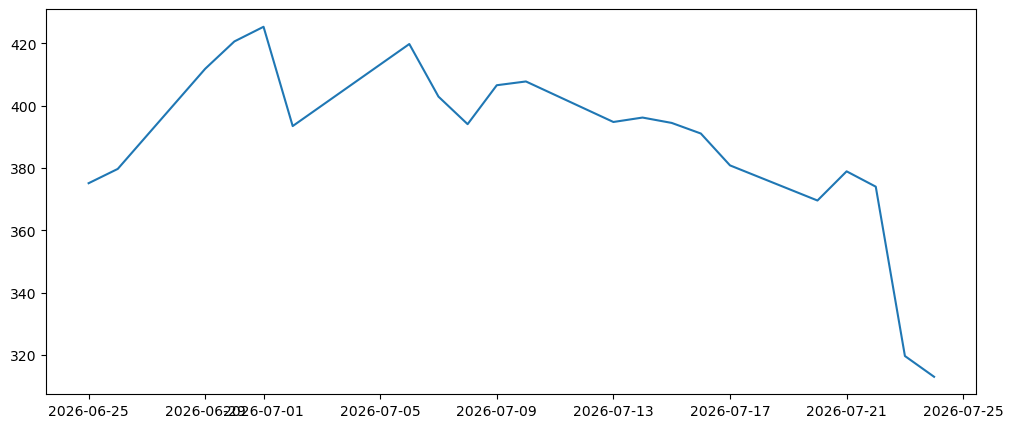

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(tesla['Close']) #x축